Name: Kushagra Raghuvanshi

Registration Number: 23BSA10072

Application Number: IN26011064

Batch Number: 2B

# LunarLander RL Project — Q-Learning, DQN, PPO, A2C, SAC

This notebook trains and evaluates multiple reinforcement learning algorithms on the **LunarLander** environment from Gymnasium:

- **Q-Learning** (tabular, hand-written, with state discretization) — `LunarLander-v3` (discrete actions)
- **DQN** (Stable-Baselines3) — `LunarLander-v3` (discrete actions)
- **PPO** (Stable-Baselines3) — `LunarLander-v3` (discrete actions)
- **A2C** (Stable-Baselines3) — `LunarLander-v3` (discrete actions)
- **SAC** (Stable-Baselines3) — `LunarLanderContinuous-v3` (continuous actions, SAC requires a continuous action space)

At the end, all algorithms are evaluated with the same protocol (mean/std reward over N episodes) and compared on a bar chart, plus training-curve plots.


In [ ]:
!pip install "gymnasium[box2d]" stable-baselines3[extra] swig -q
!apt-get install -y swig > /dev/null 2>&1
print("Installation complete.")

Installation complete.


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import torch

from stable_baselines3 import DQN, PPO, A2C, SAC
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.results_plotter import load_results, ts2xy

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DISCRETE_ENV_ID = "LunarLander-v3"        # discrete action space: Q-Learning, DQN, PPO, A2C
CONTINUOUS_ENV_ID = "LunarLanderContinuous-v3"  # continuous action space: SAC

LOG_DIR = "/content/logs"
MODEL_DIR = "/content/models"
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# Training budgets (increase these for better final performance)
TIMESTEPS_QLEARNING_EPISODES = 4000   # Q-learning counts in episodes, not steps
TIMESTEPS_DQN = 150_000
TIMESTEPS_PPO = 150_000
TIMESTEPS_A2C = 150_000
TIMESTEPS_SAC = 100_000

N_EVAL_EPISODES = 20

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


In [ ]:
env = gym.make(DISCRETE_ENV_ID)
print("Discrete env:", DISCRETE_ENV_ID)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
env.close()

cenv = gym.make(CONTINUOUS_ENV_ID)
print("\nContinuous env:", CONTINUOUS_ENV_ID)
print("Observation space:", cenv.observation_space)
print("Action space:", cenv.action_space)
cenv.close()

Discrete env: LunarLander-v3
Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space: Discrete(4)

Continuous env: LunarLanderContinuous-v3
Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space: Box(-1.0, 1.0, (2,), float32)


## 4. Q-Learning (tabular, discretized state space)

LunarLander's observation is an 8-dimensional continuous vector. Tabular Q-Learning needs a
discrete state space, so we bin each continuous dimension into a fixed number of buckets.
This is the classic/simplest RL algorithm and serves as our baseline.

In [ ]:
class QLearningAgent:
    def __init__(self, env, bins=(6, 6, 6, 6, 6, 6, 2, 2),
                 lr=0.1, gamma=0.99, eps_start=1.0, eps_end=0.05, eps_decay=0.9995):
        self.env = env
        self.bins = bins
        self.lr = lr
        self.gamma = gamma
        self.epsilon = eps_start
        self.eps_end = eps_end
        self.eps_decay = eps_decay

        # Reasonable bounds for LunarLander's 8 observation dimensions
        self.obs_low = np.array([-1.5, -1.5, -5.0, -5.0, -3.14, -5.0, -0.0, -0.0])
        self.obs_high = np.array([ 1.5,  1.5,  5.0,  5.0,  3.14,  5.0,  1.0,  1.0])

        self.n_actions = env.action_space.n
        self.q_table = np.zeros(bins + (self.n_actions,))

    def discretize(self, obs):
        obs = np.clip(obs, self.obs_low, self.obs_high)
        ratios = (obs - self.obs_low) / (self.obs_high - self.obs_low + 1e-8)
        new_state = tuple(
            int(np.clip(ratio * (b - 1), 0, b - 1)) for ratio, b in zip(ratios, self.bins)
        )
        return new_state

    def select_action(self, state, greedy=False):
        if not greedy and random.random() < self.epsilon:
            return self.env.action_space.sample()
        return int(np.argmax(self.q_table[state]))

    def update(self, state, action, reward, next_state, done):
        best_next = np.max(self.q_table[next_state])
        td_target = reward + (0 if done else self.gamma * best_next)
        td_error = td_target - self.q_table[state][action]
        self.q_table[state][action] += self.lr * td_error

    def train(self, n_episodes):
        rewards_history = []
        for ep in range(n_episodes):
            obs, _ = self.env.reset(seed=SEED + ep)
            state = self.discretize(obs)
            done = False
            total_reward = 0
            while not done:
                action = self.select_action(state)
                next_obs, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated
                next_state = self.discretize(next_obs)
                self.update(state, action, reward, next_state, done)
                state = next_state
                total_reward += reward
            self.epsilon = max(self.eps_end, self.epsilon * self.eps_decay)
            rewards_history.append(total_reward)
            if (ep + 1) % 200 == 0:
                avg = np.mean(rewards_history[-200:])
                print(f"[Q-Learning] Episode {ep+1}/{n_episodes} | avg reward (last 200): {avg:.2f} | epsilon: {self.epsilon:.3f}")
        return rewards_history

    def evaluate(self, n_episodes=20):
        total_rewards = []
        for ep in range(n_episodes):
            obs, _ = self.env.reset(seed=1000 + ep)
            state = self.discretize(obs)
            done = False
            ep_reward = 0
            while not done:
                action = self.select_action(state, greedy=True)
                obs, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated
                state = self.discretize(obs)
                ep_reward += reward
            total_rewards.append(ep_reward)
        return np.mean(total_rewards), np.std(total_rewards)

In [ ]:
ql_env = gym.make(DISCRETE_ENV_ID)
q_agent = QLearningAgent(ql_env)
ql_rewards_history = q_agent.train(TIMESTEPS_QLEARNING_EPISODES)
ql_env.close()

ql_mean, ql_std = q_agent.evaluate(N_EVAL_EPISODES)
print(f"\nQ-Learning evaluation: mean={ql_mean:.2f} +/- {ql_std:.2f}")

[Q-Learning] Episode 200/4000 | avg reward (last 200): -182.48 | epsilon: 0.905
[Q-Learning] Episode 400/4000 | avg reward (last 200): -174.35 | epsilon: 0.819
[Q-Learning] Episode 600/4000 | avg reward (last 200): -164.35 | epsilon: 0.741
[Q-Learning] Episode 800/4000 | avg reward (last 200): -163.77 | epsilon: 0.670
[Q-Learning] Episode 1000/4000 | avg reward (last 200): -173.62 | epsilon: 0.606
[Q-Learning] Episode 1200/4000 | avg reward (last 200): -160.78 | epsilon: 0.549
[Q-Learning] Episode 1400/4000 | avg reward (last 200): -185.27 | epsilon: 0.496
[Q-Learning] Episode 1600/4000 | avg reward (last 200): -182.49 | epsilon: 0.449
[Q-Learning] Episode 1800/4000 | avg reward (last 200): -176.80 | epsilon: 0.406
[Q-Learning] Episode 2000/4000 | avg reward (last 200): -194.45 | epsilon: 0.368
[Q-Learning] Episode 2200/4000 | avg reward (last 200): -184.19 | epsilon: 0.333
[Q-Learning] Episode 2400/4000 | avg reward (last 200): -192.02 | epsilon: 0.301
[Q-Learning] Episode 2600/4000 |

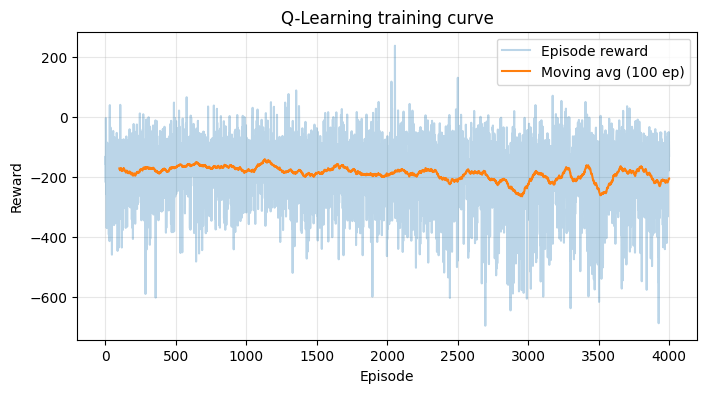

In [ ]:
def moving_average(x, w=100):
    return np.convolve(x, np.ones(w) / w, mode="valid")

plt.figure(figsize=(8, 4))
plt.plot(ql_rewards_history, alpha=0.3, label="Episode reward")
if len(ql_rewards_history) >= 100:
    plt.plot(range(99, len(ql_rewards_history)), moving_average(ql_rewards_history, 100), label="Moving avg (100 ep)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Q-Learning training curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. Deep RL agents with Stable-Baselines3

For DQN, PPO, and A2C we use the discrete `LunarLander-v3` environment.
For SAC (which only supports continuous action spaces) we use `LunarLanderContinuous-v3`.

Each agent is trained with a `Monitor` wrapper so we can plot the training curve from logged
episode rewards, and each is evaluated with `evaluate_policy` for a fair, consistent comparison.

In [ ]:
def make_monitored_env(env_id, log_subdir):
    log_path = os.path.join(LOG_DIR, log_subdir)
    os.makedirs(log_path, exist_ok=True)
    env = gym.make(env_id)
    env = Monitor(env, filename=os.path.join(log_path, "monitor"))
    return env

def plot_training_curve(log_subdir, title):
    log_path = os.path.join(LOG_DIR, log_subdir)
    try:
        x, y = ts2xy(load_results(log_path), "timesteps")
    except Exception as e:
        print("Could not load results for", log_path, ":", e)
        return
    plt.figure(figsize=(8, 4))
    plt.plot(x, y, alpha=0.3, label="Episode reward")
    if len(y) >= 20:
        plt.plot(x[19:], moving_average(y, 20), label="Moving avg (20 ep)")
    plt.xlabel("Timesteps")
    plt.ylabel("Reward")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

### 5.1 DQN

In [ ]:
dqn_env = make_monitored_env(DISCRETE_ENV_ID, "dqn")

dqn_model = DQN(
    "MlpPolicy",
    dqn_env,
    learning_rate=1e-3,
    buffer_size=100_000,
    learning_starts=1000,
    batch_size=64,
    gamma=0.99,
    train_freq=4,
    target_update_interval=1000,
    exploration_fraction=0.2,
    exploration_final_eps=0.05,
    verbose=1,
    seed=SEED,
    device=device,
)
dqn_model.learn(total_timesteps=TIMESTEPS_DQN)
dqn_model.save(os.path.join(MODEL_DIR, "dqn_lunarlander"))
dqn_env.close()

Using cpu device
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 95.5     |
|    ep_rew_mean      | -180     |
|    exploration_rate | 0.988    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 4154     |
|    time_elapsed     | 0        |
|    total_timesteps  | 382      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 93.2     |
|    ep_rew_mean      | -209     |
|    exploration_rate | 0.976    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 4166     |
|    time_elapsed     | 0        |
|    total_timesteps  | 746      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 94.8     |
|    ep_rew_mean      | -224     |
|    exploration_rate | 0.964    |
| t

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


DQN evaluation: mean=5.85 +/- 80.06


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


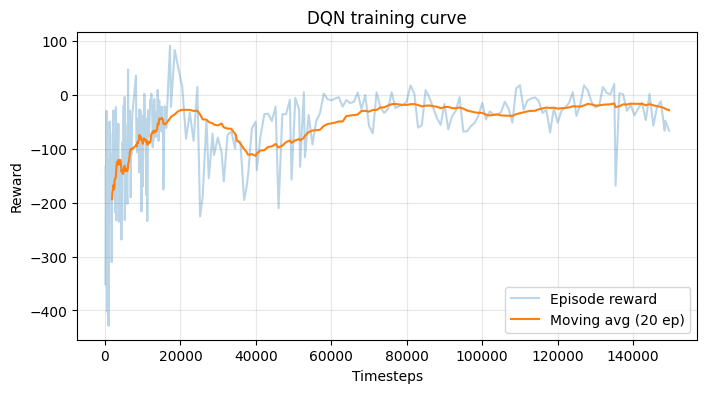

In [ ]:
eval_env_dqn = gym.make(DISCRETE_ENV_ID)
dqn_mean, dqn_std = evaluate_policy(dqn_model, eval_env_dqn, n_eval_episodes=N_EVAL_EPISODES)
eval_env_dqn.close()
print(f"DQN evaluation: mean={dqn_mean:.2f} +/- {dqn_std:.2f}")
plot_training_curve("dqn", "DQN training curve")

### 5.2 PPO

In [ ]:
ppo_env = make_monitored_env(DISCRETE_ENV_ID, "ppo")

ppo_model = PPO(
    "MlpPolicy",
    ppo_env,
    learning_rate=3e-4,
    n_steps=1024,
    batch_size=64,
    n_epochs=10,
    gamma=0.999,
    gae_lambda=0.98,
    ent_coef=0.01,
    verbose=1,
    seed=SEED,
    device=device,
)
ppo_model.learn(total_timesteps=TIMESTEPS_PPO)
ppo_model.save(os.path.join(MODEL_DIR, "ppo_lunarlander"))
ppo_env.close()

Using cpu device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 82.7     |
|    ep_rew_mean     | -140     |
| time/              |          |
|    fps             | 859      |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 1024     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 89           |
|    ep_rew_mean          | -217         |
| time/                   |              |
|    fps                  | 741          |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0057351794 |
|    clip_fraction        | 0.00586      |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.38        |
|    e

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


PPO evaluation: mean=65.67 +/- 134.73


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


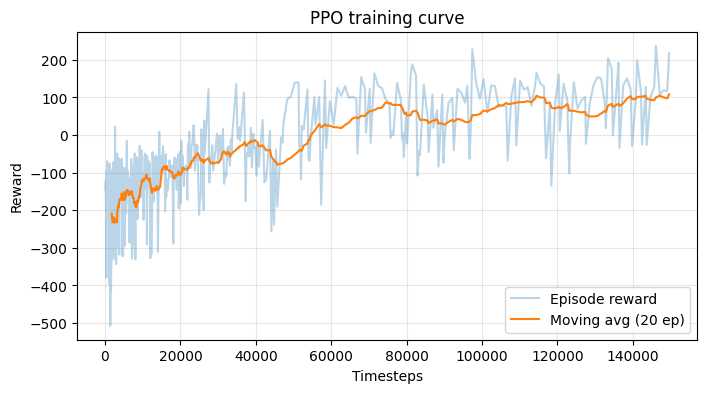

In [ ]:
eval_env_ppo = gym.make(DISCRETE_ENV_ID)
ppo_mean, ppo_std = evaluate_policy(ppo_model, eval_env_ppo, n_eval_episodes=N_EVAL_EPISODES)
eval_env_ppo.close()
print(f"PPO evaluation: mean={ppo_mean:.2f} +/- {ppo_std:.2f}")
plot_training_curve("ppo", "PPO training curve")

### 5.3 A2C

In [ ]:
a2c_env = make_monitored_env(DISCRETE_ENV_ID, "a2c")

a2c_model = A2C(
    "MlpPolicy",
    a2c_env,
    learning_rate=7e-4,
    n_steps=8,
    gamma=0.99,
    ent_coef=0.01,
    verbose=1,
    seed=SEED,
    device=device,
)
a2c_model.learn(total_timesteps=TIMESTEPS_A2C)
a2c_model.save(os.path.join(MODEL_DIR, "a2c_lunarlander"))
a2c_env.close()

Using cpu device
Wrapping the env in a DummyVecEnv.
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 111      |
|    ep_rew_mean        | -381     |
| time/                 |          |
|    fps                | 731      |
|    iterations         | 100      |
|    time_elapsed       | 1        |
|    total_timesteps    | 800      |
| train/                |          |
|    entropy_loss       | -1.03    |
|    explained_variance | -0.0226  |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | -6.23    |
|    value_loss         | 38.8     |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 117      |
|    ep_rew_mean        | -385     |
| time/                 |          |
|    fps                | 715      |
|    iterations         | 200      |
|    time_elapsed       | 2        |
|    total_timesteps   

In [ ]:
eval_env_a2c = gym.make(DISCRETE_ENV_ID)
a2c_mean, a2c_std = evaluate_policy(a2c_model, eval_env_a2c, n_eval_episodes=N_EVAL_EPISODES)
eval_env_a2c.close()
print(f"A2C evaluation: mean={a2c_mean:.2f} +/- {a2c_std:.2f}")
plot_training_curve("a2c", "A2C training curve")

### 5.4 SAC (continuous control)

SAC requires a continuous action space, so it is trained on `LunarLanderContinuous-v3`
instead of the discrete environment used above. This means its score is not perfectly
apples-to-apples with the discrete agents, but the reward scale and landing task are the same.

In [ ]:
sac_env = make_monitored_env(CONTINUOUS_ENV_ID, "sac")

sac_model = SAC(
    "MlpPolicy",
    sac_env,
    learning_rate=3e-4,
    buffer_size=100_000,
    learning_starts=1000,
    batch_size=256,
    gamma=0.99,
    tau=0.005,
    train_freq=1,
    verbose=1,
    seed=SEED,
    device=device,
)
sac_model.learn(total_timesteps=TIMESTEPS_SAC)
sac_model.save(os.path.join(MODEL_DIR, "sac_lunarlander"))
sac_env.close()

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


SAC evaluation: mean=-45.04 +/- 40.70


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


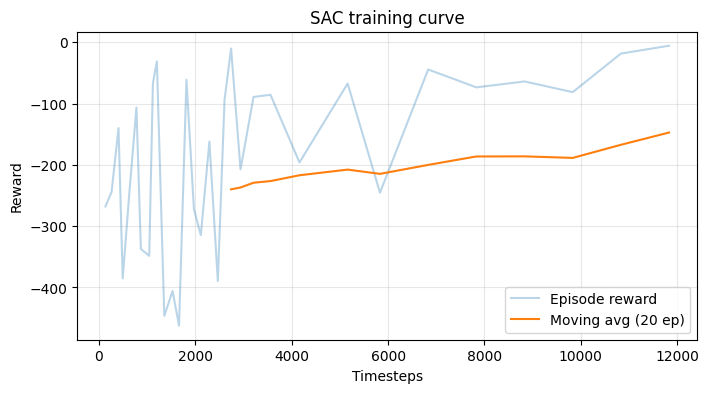

In [ ]:
eval_env_sac = gym.make(CONTINUOUS_ENV_ID)
sac_mean, sac_std = evaluate_policy(sac_model, eval_env_sac, n_eval_episodes=N_EVAL_EPISODES)
eval_env_sac.close()
print(f"SAC evaluation: mean={sac_mean:.2f} +/- {sac_std:.2f}")
plot_training_curve("sac", "SAC training curve")

## 6. Compare all algorithms

Algorithm            Mean Reward       Std
Q-Learning               -166.33     43.79
DQN                         5.85     80.06
PPO                        65.67    134.73
A2C                       -70.78     29.70
SAC (continuous)          -45.04     40.70


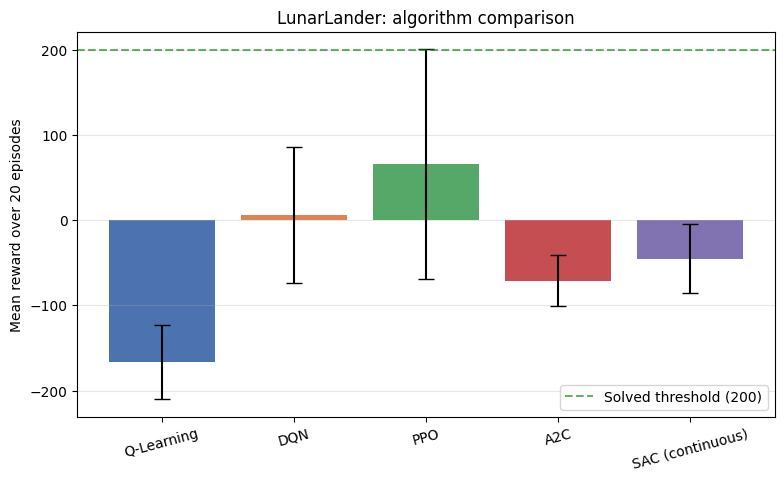

In [ ]:
results = {
    "Q-Learning": (ql_mean, ql_std),
    "DQN": (dqn_mean, dqn_std),
    "PPO": (ppo_mean, ppo_std),
    "A2C": (a2c_mean, a2c_std),
    "SAC (continuous)": (sac_mean, sac_std),
}

print(f"{'Algorithm':<18}{'Mean Reward':>14}{'Std':>10}")
for name, (m, s) in results.items():
    print(f"{name:<18}{m:>14.2f}{s:>10.2f}")

names = list(results.keys())
means = [results[n][0] for n in names]
stds = [results[n][1] for n in names]

plt.figure(figsize=(9, 5))
bars = plt.bar(names, means, yerr=stds, capsize=6, color=["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"])
plt.axhline(200, color="green", linestyle="--", alpha=0.6, label="Solved threshold (200)")
plt.ylabel(f"Mean reward over {N_EVAL_EPISODES} episodes")
plt.title("LunarLander: algorithm comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)
plt.show()